## Step 1: Setting up the Environment

![frozen_lake](https://gymnasium.farama.org/_images/frozen_lake.gif)

### 1.1: Environment Overview
The FrozenLake environment is a grid world where an agent must reach the goal (`G`) from the start (`S`) while avoiding holes (`H`).

**Key Concepts for Students:**
- **State Space**: 16 discrete states (in a 4x4 grid).
- **Action Space**: 4 discrete actions: Left (0), Down (1), Right (2), Up (3).
- **Sparse Rewards**: You only get a reward (+1) when you reach the goal. Everything else is 0.
- **Stochasticity (Slippery Ice)**: If `is_slippery=True`, the agent might not move in the intended direction, representing a Markov Decision Process (MDP) with uncertain transitions.

In [22]:
!apt-get install -y xvfb x11-utils
%pip install pyvirtualdisplay
%pip install gymnasium[toy_text]
%pip install swig

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
x11-utils is already the newest version (7.7+5build2).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [23]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display

# Set up virtual display
display = Display(visible=0, size=(1400, 900))
display.start()

In [24]:
# Making Frozen Lake Environment
env = gym.make('FrozenLake-v1', is_slippery=True, render_mode='rgb_array')

In [25]:
# Size of observation space (state space)
env.observation_space.n

np.int64(16)

In [26]:
# Size of action space
env.action_space.n

np.int64(4)

In [27]:
# 💡 TUTORIAL TIP: In Gymnasium, transition dynamics are stored in the core environment.
# We use '.unwrapped' to look under the hood at the MDP probabilities.
# Format: {state: {action: [(probability, next_state, reward, is_terminal), ...]}}

state_to_inspect = 0
action_to_inspect = 1 # 1 is 'Down'

transitions = env.unwrapped.P[state_to_inspect][action_to_inspect]
print(f"Transitions for State {state_to_inspect}, Action {action_to_inspect}:\n{transitions}")

Transitions for State 0, Action 1:
[(0.33333333333333337, 0, 0, False), (0.3333333333333333, 4, 0, False), (0.33333333333333337, 1, 0, False)]


### 🕹️ The Gymnasium API: step() and reset()

In this tutorial, we use **Gymnasium** (the maintained fork of OpenAI Gym). It's important to understand the standard API for environment interaction.

#### 1. `env.reset()`
Resets the environment to its initial state.
- **Returns**: `(observation, info)`

#### 2. `env.step(action)`
Advances the environment by one timestep.
- **Returns**: `(observation, reward, terminated, truncated, info)`

> **Note for Students:**
> - `terminated`: True if the agent reaches a Goal or falls in a Hole.
> - `truncated`: True if the episode ends due to a time limit or external constraint.
> - We use `done = terminated or truncated` to handle both cases.

In [28]:
# Reset the environment and return initial state
# Gymnasium reset() returns (obs, info)
start_state, info = env.reset()
print(start_state)

0


In [29]:
# Initialize environment if not already present
import gymnasium as gym
try:
    env
except NameError:
    env = gym.make('FrozenLake-v1', is_slippery=True, render_mode='rgb_array')

# Gymnasium step function returns 5 values: obs, reward, terminated, truncated, info
env.reset()
action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)

# Combine termination flags for backward compatibility if needed
done = terminated or truncated

print(f"Action: {action}, Observation: {obs}, Reward: {reward}, is_done: {done}, info: {info}")

Action: 3, Observation: 0, Reward: 0, is_done: False, info: {'prob': 0.3333333333333333}


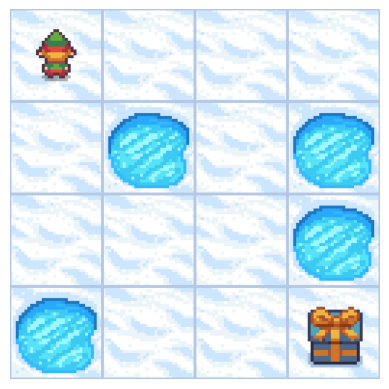

In [30]:
ipythondisplay.clear_output(wait=True)
# In gymnasium, render() uses the mode defined at initialization
plt.imshow(env.render())
plt.axis('off')
plt.show()

## Exercise 1:

#### 1.1 Define an MDP for FrozenLake environment in 8x8 grid with and without slippery. Compare the transition probability function in slippery and non-slippery versions. Run a full episode of both version and compare the behavior of the agent.
#### 1.2 Calculate the transition probability matrix analytically by hand and compare it with the one given by gym.

In [31]:
env2 = gym.make("FrozenLake-v1", is_slippery=False, map_name="8x8", render_mode='rgb_array')

In [32]:
env2.observation_space.n

np.int64(64)

In [33]:
env2.action_space.n

np.int64(4)

In [34]:
# Accessing transition dynamics for the 8x8 environment
env2.unwrapped.P

{0: {0: [(1.0, 0, 0, False)],
  1: [(1.0, 8, 0, False)],
  2: [(1.0, 1, 0, False)],
  3: [(1.0, 0, 0, False)]},
 1: {0: [(1.0, 0, 0, False)],
  1: [(1.0, 9, 0, False)],
  2: [(1.0, 2, 0, False)],
  3: [(1.0, 1, 0, False)]},
 2: {0: [(1.0, 1, 0, False)],
  1: [(1.0, 10, 0, False)],
  2: [(1.0, 3, 0, False)],
  3: [(1.0, 2, 0, False)]},
 3: {0: [(1.0, 2, 0, False)],
  1: [(1.0, 11, 0, False)],
  2: [(1.0, 4, 0, False)],
  3: [(1.0, 3, 0, False)]},
 4: {0: [(1.0, 3, 0, False)],
  1: [(1.0, 12, 0, False)],
  2: [(1.0, 5, 0, False)],
  3: [(1.0, 4, 0, False)]},
 5: {0: [(1.0, 4, 0, False)],
  1: [(1.0, 13, 0, False)],
  2: [(1.0, 6, 0, False)],
  3: [(1.0, 5, 0, False)]},
 6: {0: [(1.0, 5, 0, False)],
  1: [(1.0, 14, 0, False)],
  2: [(1.0, 7, 0, False)],
  3: [(1.0, 6, 0, False)]},
 7: {0: [(1.0, 6, 0, False)],
  1: [(1.0, 15, 0, False)],
  2: [(1.0, 7, 0, False)],
  3: [(1.0, 7, 0, False)]},
 8: {0: [(1.0, 8, 0, False)],
  1: [(1.0, 16, 0, False)],
  2: [(1.0, 9, 0, False)],
  3: [(1.0, 0



### Step 2. Calculate state-action value function `Q(s,a)`

#### Expected Value Calculation:

Given state $s$ and action $a$, the expected value of performing action $a$ in state $s$ is:

$Q(s,a) = \sum_{s'} P(s' | s, a) [R(s,a,s') + \gamma V(s')]$

Where:
- $P(s' | s, a)$ is the transition probability from state $s$ to state $s'$ upon taking action $a$.
- $R(s,a,s')$ is the reward for moving from state $s$ to state $s'$ due to action $a$.
- $\gamma$ is the discount factor.
- $V(s')$ is the value of the next state $s'$.

In [35]:
def compute_value_for_action(env, state, action, V, gamma):
    """
    Calculates the expected value of an action using the Bellman Equation.
    Q(s,a) = sum(P(s'|s,a) * [R + gamma * V(s')])
    """
    value = 0
    # We use .unwrapped to access the transition table P
    for prob, next_state, reward, done in env.unwrapped.P[state][action]:
        value += prob * (reward + gamma * V[next_state])
    return value


### Step 3. Policy Iteration Algorithm

Policy Iteration involves two main steps:

1. **Policy Evaluation**: Estimate the state-value function for the current policy.
2. **Policy Improvement**: Derive a new policy from the current value function.

Formulations:
1. Policy Evaluation:

$V^\pi(s) = \sum_a \pi(a|s) \sum_{s'} P(s' | s, a) [R(s,a,s') + \gamma V^\pi(s')]$

2. Policy Improvement:

$\pi'(s) = \arg\max_a Q(s,a)$

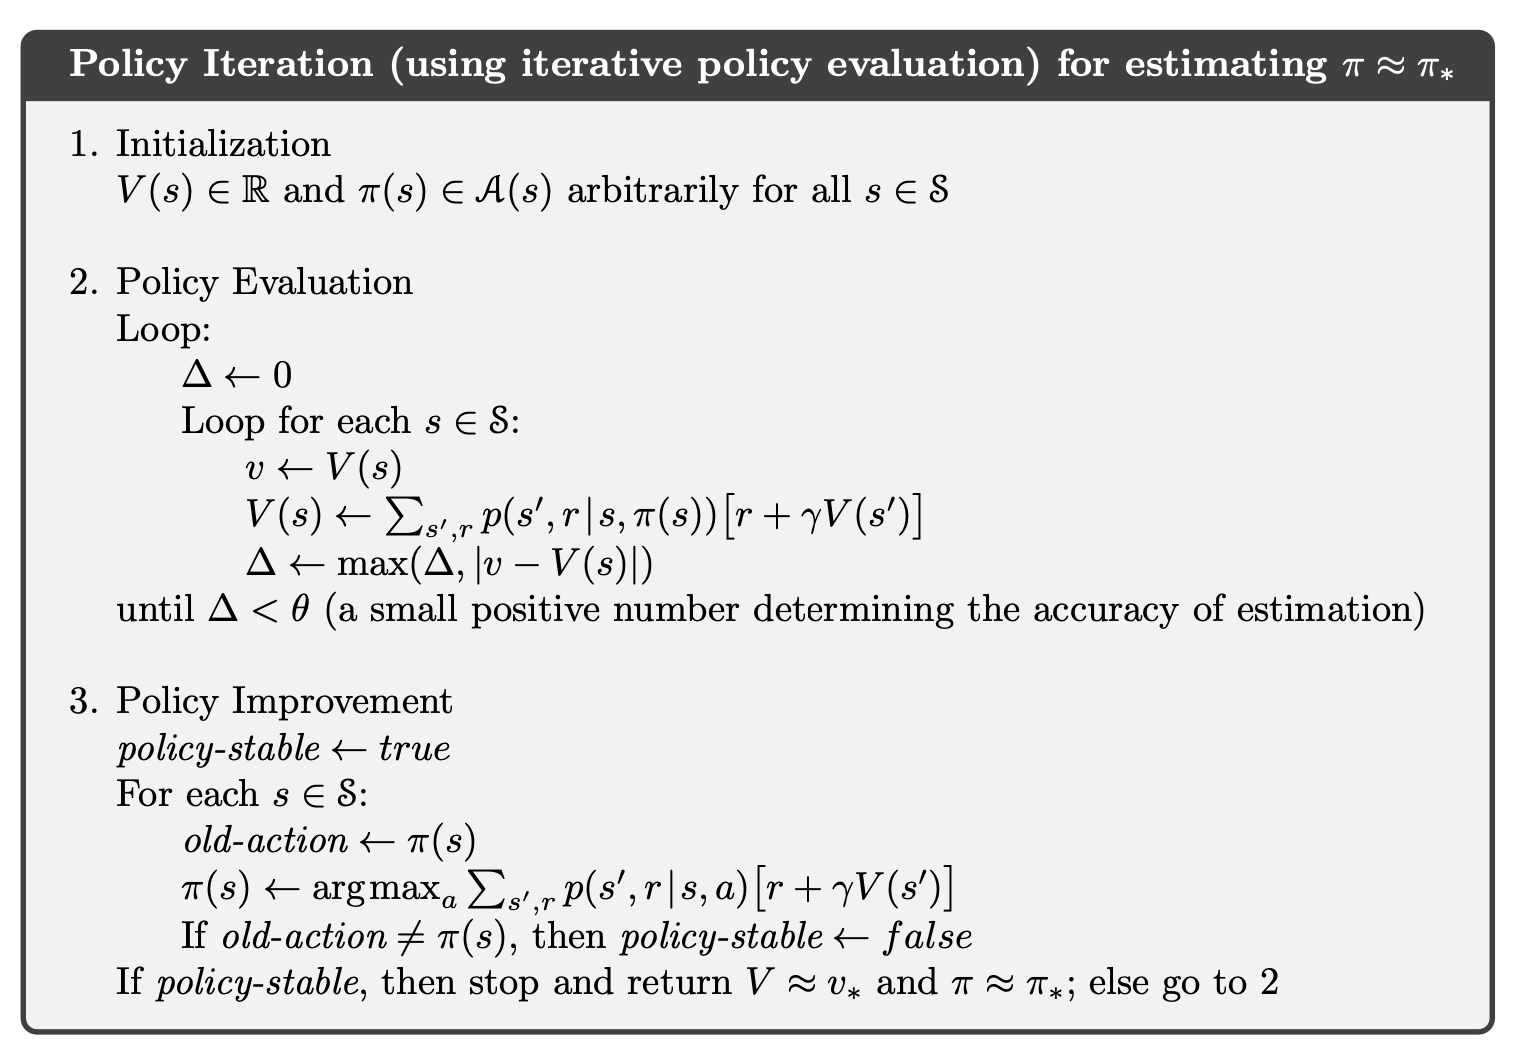

### 3.1 Policy Evaluation
In this step, we compute the state-value function $V^\pi$ for a fixed policy $\pi$. We iteratively update the values using the Bellman expectation equation until they converge (change less than $\theta$).

In [36]:
def policy_evaluation(policy, env, gamma, theta):
    """Iteratively evaluate a policy until convergence (delta < theta)"""
    V = np.zeros(env.observation_space.n)
    while True:
        delta = 0
        for state in range(env.observation_space.n):
            v = 0
            for action, action_prob in enumerate(policy[state]):
                v += action_prob * compute_value_for_action(env, state, action, V, gamma)
            delta = max(delta, np.abs(v - V[state]))
            V[state] = v
        if delta < theta:
            break
    return V

### 3.2 Policy Improvement
Once we have the value function for the current policy, we update the policy to be 'greedy' with respect to those values. We pick the action that maximizes the expected return.

In [37]:
def policy_improvement(V, env, gamma):
    policy = np.zeros([env.observation_space.n, env.action_space.n])
    for state in range(env.observation_space.n):
        q_values = [compute_value_for_action(env, state, action, V, gamma) for action in range(env.action_space.n)]
        best_action = np.argmax(q_values)
        policy[state, best_action] = 1.0
    return policy

### 3.3 Policy Iteration

In [38]:
def policy_iteration(env, gamma=0.9, theta=1e-3):
    """Policy Iteration Algorithm: Evaluation -> Improvement"""
    policy = np.ones([env.observation_space.n, env.action_space.n]) / env.action_space.n
    num_improvements = 0
    while True:
        num_improvements += 1
        # policy_evaluation now returns just V
        V = policy_evaluation(policy, env, gamma, theta)
        new_policy = policy_improvement(V, env, gamma)

        # Check if policy is stable
        if (new_policy == policy).all():
            break
        policy = new_policy
    return num_improvements, policy, V

### Step 4: Value Iteration

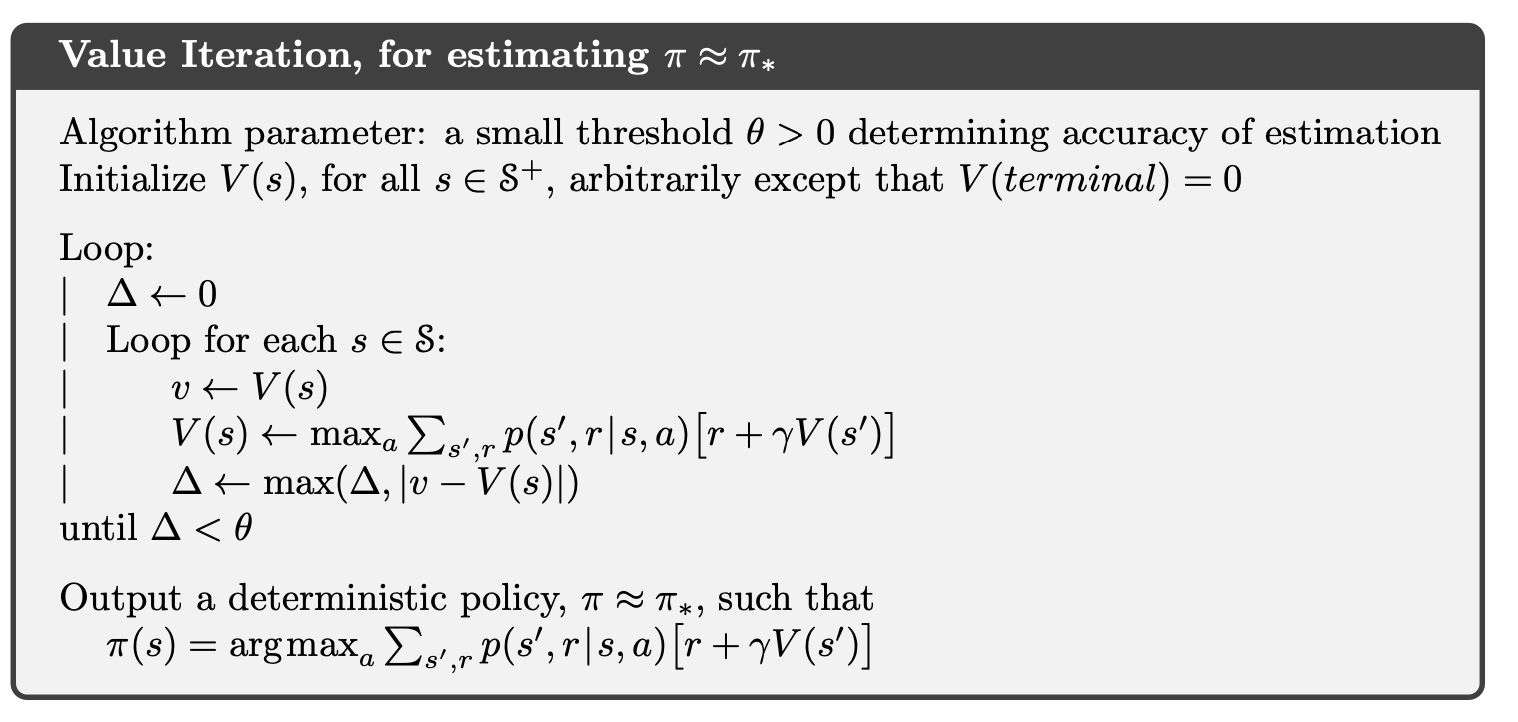



### 4.1: Implementing Value Iteration:

In [39]:
def value_iteration(env, theta=1e-3, gamma=0.9):
    iter = 0
    V = np.zeros(env.observation_space.n)
    while True:
        iter += 1
        delta = 0
        for state in range(env.observation_space.n):
            action_values = np.array([compute_value_for_action(env, state, action, V, gamma) for action in range(env.action_space.n)])
            best_action_value = np.max(action_values)
            delta = max(delta, np.abs(best_action_value - V[state]))
            V[state] = best_action_value
        if delta < theta:
            break
    policy = np.zeros([env.observation_space.n, env.action_space.n])
    for state in range(env.observation_space.n):
        action_values = np.array([compute_value_for_action(env, state, action, V, gamma) for action in range(env.action_space.n)])
        best_action = np.argmax(action_values)
        policy[state, best_action] = 1.0
    return iter, policy, V

### Step 5: Running and Comparing Algorithms

In [40]:
# Run Value Iteration
VI_iter, value_policy, value_V = value_iteration(env)

# Run Policy Iteration
PI_iter, policy_policy, policy_V = policy_iteration(env)

print("\nPolicy Iteration Policy:")
print(policy_policy)
print("Policy Iteration Value Function:")
print(policy_V)
print("Number of Iterations:")
print(PI_iter)

print("Value Iteration Policy:")
print(value_policy)
print("Value Iteration Value Function:")
print(value_V)
print("Number of Iterations:")
print(VI_iter)


Policy Iteration Policy:
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]
Policy Iteration Value Function:
[0.06476289 0.05841569 0.07252933 0.05378964 0.08867795 0.
 0.11137269 0.         0.14325408 0.24628655 0.29886952 0.
 0.         0.37915415 0.63865133 0.        ]
Number of Iterations:
3
Value Iteration Policy:
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]
Value Iteration Value Function:
[0.06428821 0.05807365 0.07231299 0.05356057 0.08830336 0.
 0.11127288 0.         0.14298808 0.24613328 0.29877497 0.
 0.         0.37905097 0.63860174 0.        ]
Number of Iterations:
23


In [41]:
def run_episode(env, policy, render=False):
    state, info = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = np.argmax(policy[state])
        # Unpack the 5 values from gymnasium
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward

        if render:
            ipythondisplay.clear_output(wait=True)
            plt.imshow(env.render())
            plt.axis('off')
            plt.show()
            print(f"Episode Reward: {total_reward}")

        state = next_state
    print(total_reward)
    return total_reward

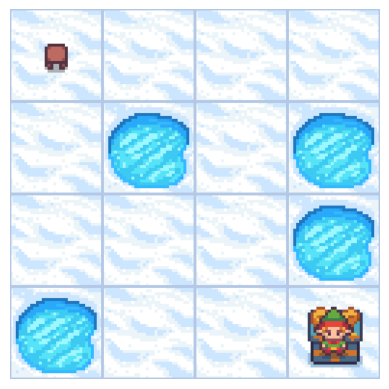

Episode Reward: 1
1


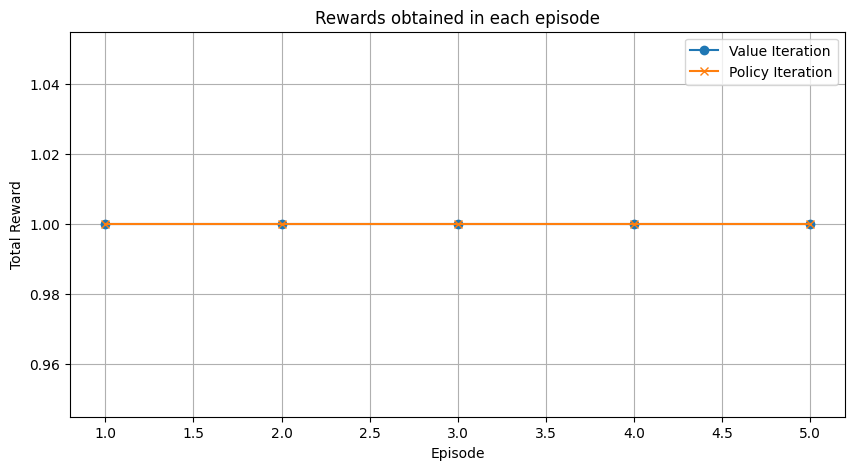

In [42]:
# Run episodes using learned policies
num_episodes = 5
value_iter_rewards = [run_episode(env, value_policy, render=True) for _ in range(num_episodes)]
policy_iter_rewards = [run_episode(env, policy_policy, render=True) for _ in range(num_episodes)]
# policy_iter_rewards = [run_episode(env, optimal_policy, render=True) for _ in range(num_episodes)]


# Plot rewards
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_episodes + 1), value_iter_rewards, label="Value Iteration", marker='o')
plt.plot(range(1, num_episodes + 1), policy_iter_rewards, label="Policy Iteration", marker='x')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Rewards obtained in each episode")
plt.legend()
plt.grid(True)
plt.show()

## Exercise 2:

Re-run value iteration and policy iteration algorithms in FrozenLake environment with 8x8, with and without slippery setup. Compare the number of iterations with 4x4. How does slippery setup affect on speed of convergence?

In [43]:
env2 = gym.make("FrozenLake-v1", is_slippery=False, map_name="8x8", render_mode='rgb_array')

In [44]:
# Run Value Iteration
VI_iter, value_policy, value_V = value_iteration(env2)

# Run Policy Iteration
PI_iter, policy_policy, policy_V = policy_iteration(env2)

print("\nPolicy Iteration Policy:")
print(policy_policy)
print("Policy Iteration Value Function:")
print(policy_V)
print("Number of Iterations:")
print(PI_iter)

print("Value Iteration Policy:")
print(value_policy)
print("Value Iteration Value Function:")
print(value_V)
print("Number of Iterations:")
print(VI_iter)


Policy Iteration Policy:
[[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]]
Policy Iterat

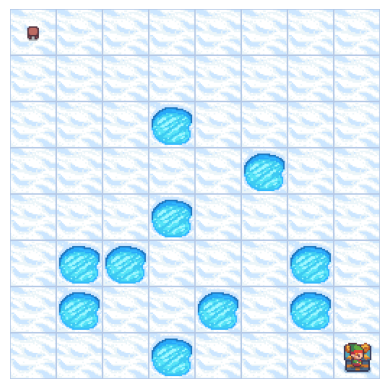

Episode Reward: 1
1


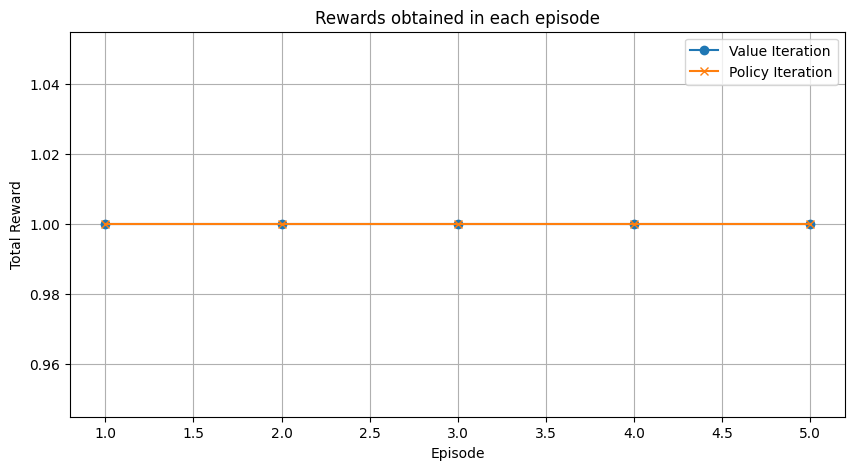

In [45]:
# Run episodes using learned policies
num_episodes = 5
value_iter_rewards = [run_episode(env2, value_policy, render=True) for _ in range(num_episodes)]
policy_iter_rewards = [run_episode(env2, policy_policy, render=True) for _ in range(num_episodes)]

# Plot rewards
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_episodes + 1), value_iter_rewards, label="Value Iteration", marker='o')
plt.plot(range(1, num_episodes + 1), policy_iter_rewards, label="Policy Iteration", marker='x')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Rewards obtained in each episode")
plt.legend()
plt.grid(True)
plt.show()